# Analysis of the change of environment. 

In [1]:
import os 
import json 
import dill 
import matplotlib.pyplot as plt
import numpy as np
import sys

from base_fns import get_local_file
file = get_local_file()

local_dir = os.path.dirname(os.path.dirname(file))
sys.path.append(local_dir)


def transitions(all_gens, switch, kind):
    # les changements d'env arrivent aux multiples de switch (20, 40, 60...)
    # n impair -> on passe a l'env 1 ; n pair -> on passe a l'env 0
    # le debut du nouvel env est a n*switch, la fin de l'ancien juste avant a n*switch - 1
    # kind vaut 'start_0to1', 'start_1to0', 'end_env0' ou 'end_env1'
    generations = max(all_gens)
    res = []
    n = 1
    while n * switch <= generations:
        if n % 2 == 1:            # on passe a l'env 1
            if kind == 'start_0to1': res.append(n * switch)
            if kind == 'end_env0':   res.append(n * switch - 1)
        else:                     # on passe a l'env 0
            if kind == 'start_1to0': res.append(n * switch)
            if kind == 'end_env1':   res.append(n * switch - 1)
        n += 1
    return res

In [2]:
# to change 
path = 'changingenv10'
number = 1
start_gen = 60         # on ignore les generations avant start_gen (temps de convergence)
# end of to change 

results_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(number))
haploid_dir = os.path.join(results_dir, 'haploid')
diploid_dir = os.path.join(results_dir, 'diploid')
json_haploid_dir = os.path.join(haploid_dir, 'json')
json_diploid_dir = os.path.join(diploid_dir, 'json')
file = 'configs.json'
haploid_json_dir_file = os.path.join(json_haploid_dir, file)
diploid_json_dir_file = os.path.join(json_diploid_dir, file)
with open(haploid_json_dir_file, 'r') as f : 
    haploid_data_config = json.load(f)

result = ''
for key, value in haploid_data_config.items():
    result += f'{key} : {value}\n'

with open(diploid_json_dir_file, 'r') as f : 
    diploid_data_config = json.load(f)

diploid_result = ''
for key, value in diploid_data_config.items():
    diploid_result += f'{key} : {value}\n'

print(result)
print(diploid_result)

number_of_exp : 2
number_of_config : 1
threshold_var : 0.15
body_shape : [5, 5]
max_weight : 1
max_bias : 1
response : 1
max_weight_cppn : 20
max_bias_cppn : 20
range_weight : 1
range_bias : 1
sigma_weight : 0.1
sigma_bias : 0.1
sigma_dominance : 0.15
threshold_weight : 0.05
threshold_bias : 0.03
threshold_function : 0.03
threshold_dominance : 0.07
switch : 30
generations : 330
population : 128
number_of_winner : 1
number_in_tournament : 3
number_of_elites : 2
shape_of_cppn : [[11], [5], [3, 3], [1, 1]]
function_pool : ['gaussian', 'sin', 'tanh']
n_steps : [1000, 600]
number_of_reported_individuals : 40
cpus : 32
env_name : ['Pusher-v0', 'Walker-v0']

number_of_exp : 2
number_of_config : 1
threshold_var : 0.15
body_shape : [5, 5]
max_weight : 1
max_bias : 1
response : 1
max_weight_cppn : 20
max_bias_cppn : 20
range_weight : 1
range_bias : 1
sigma_weight : 0.1
sigma_bias : 0.1
sigma_dominance : 0.15
threshold_weight : 0.05
threshold_bias : 0.03
threshold_function : 0.03
threshold_domina

In [3]:
switch = haploid_data_config['switch']

best_haploid = [] ; avgbest_haploid = []      # une case (dico gen->valeur) par id
best_diploid = [] ; avgbest_diploid = []

for k in range(haploid_data_config['number_of_config']) :
    for i in range(diploid_data_config['number_of_exp']) :
        id_exp = number + k * diploid_data_config['number_of_exp'] + i

        # --- haploid ---
        pkl_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(id_exp), 'haploid', 'pkl')
        for file in os.listdir(pkl_dir) :
            if file.endswith('statistic_registry.pkl') :
                file_dir = os.path.join(pkl_dir, file)
                with open(file_dir, 'rb') as f :
                    loaded_file = dill.load(f)
        best = {} ; avg = {}
        for statistic in loaded_file.values() :
            best[statistic.generation] = statistic.fitness
            avg[statistic.generation] = statistic.average_best
        best_haploid.append(best)
        avgbest_haploid.append(avg)

        # --- diploid ---
        pkl_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(id_exp), 'diploid', 'pkl')
        for file in os.listdir(pkl_dir) :
            if file.endswith('statistic_registry.pkl') :
                file_dir = os.path.join(pkl_dir, file)
                with open(file_dir, 'rb') as f :
                    loaded_file = dill.load(f)
        best = {} ; avg = {}
        for statistic in loaded_file.values() :
            best[statistic.generation] = statistic.fitness
            avg[statistic.generation] = statistic.average_best
        best_diploid.append(best)
        avgbest_diploid.append(avg)

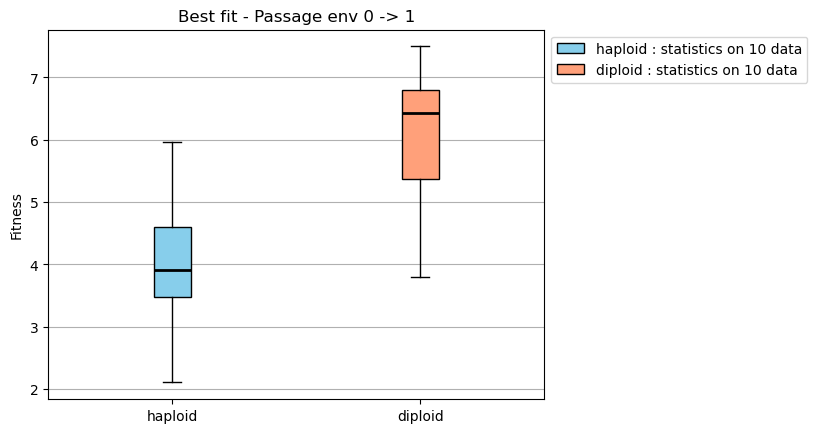

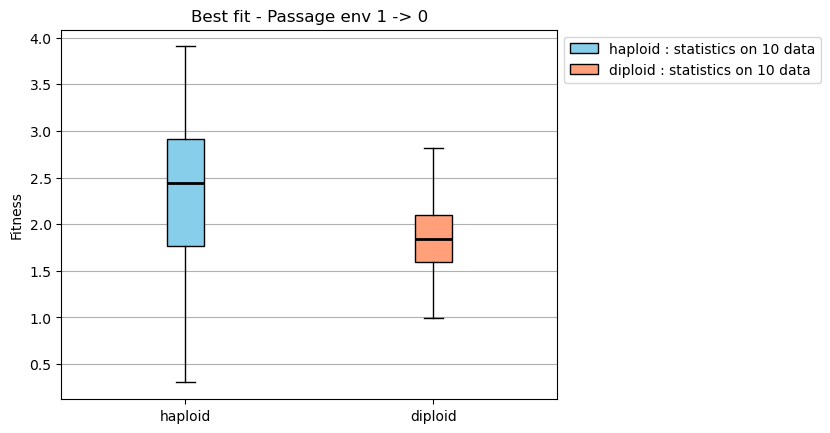

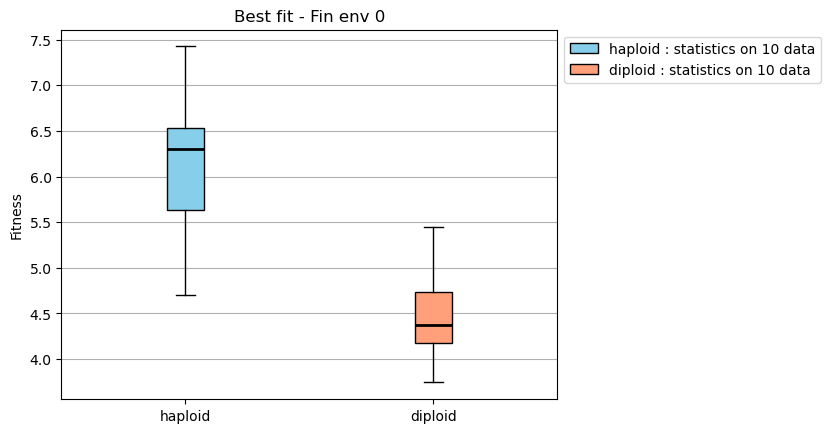

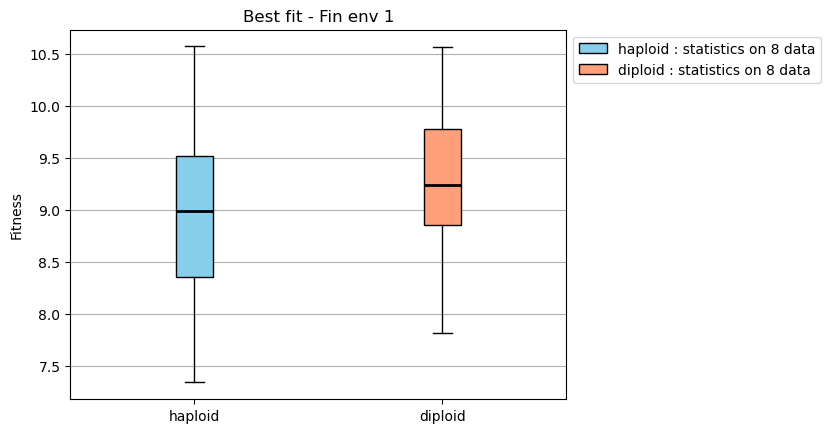

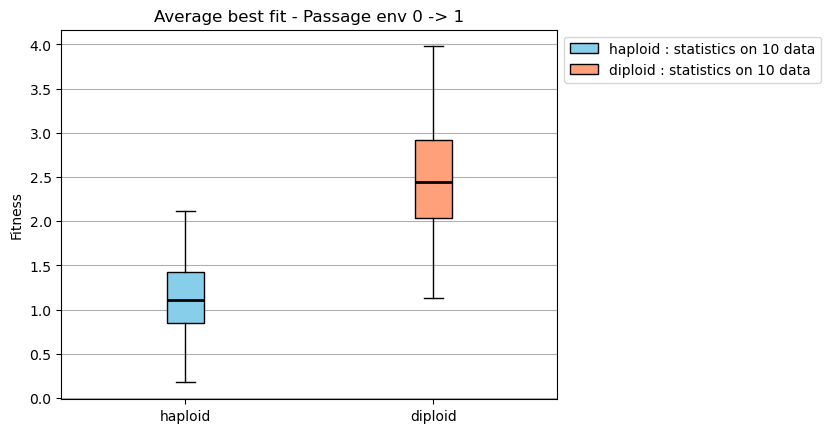

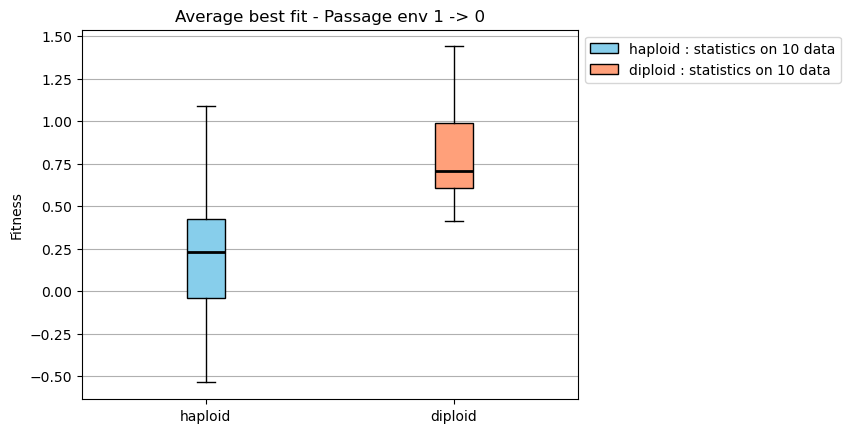

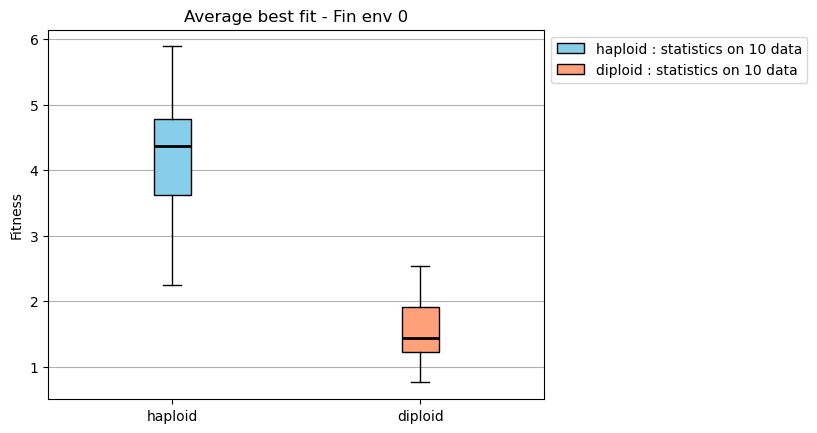

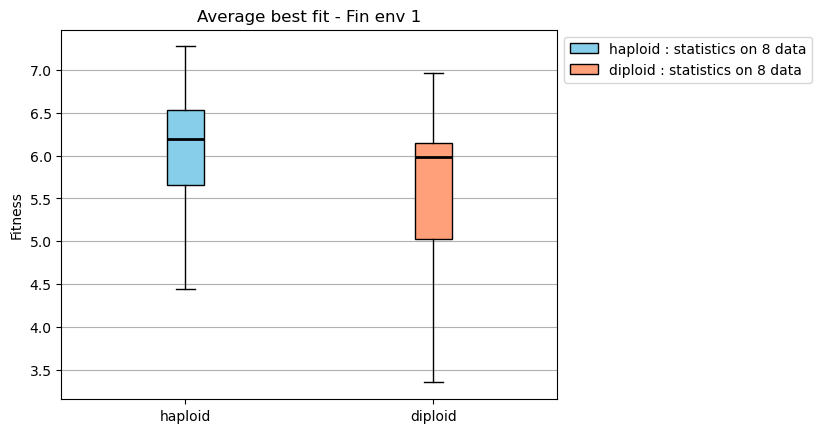

In [4]:
def pool(list_par_id, kind) :
    # rassemble toutes les valeurs de la categorie kind, sur tous les ids
    valeurs = []
    for d in list_par_id :
        gens = transitions(sorted(d.keys()), switch, kind)
        for g in gens :
            if g >= start_gen :
                valeurs.append(d[g])
    return valeurs


def candle(valeurs, label) :
    # stats d'une bougie pour ax.bxp :
    # trait central = moyenne ; boite = ecart-type des points au-dessus / en-dessous de la moyenne ;
    # moustaches = min et max (bxp met des traits horizontaux aux bouts et aux bords de la boite)
    v = np.array(valeurs)
    m = v.mean()
    dessus = v[v > m]
    dessous = v[v < m]
    std_dessus = dessus.std() if len(dessus) else 0.0
    std_dessous = dessous.std() if len(dessous) else 0.0
    return {'label' : label, 'med' : m,
            'q1' : m - std_dessous, 'q3' : m + std_dessus,
            'whislo' : v.min(), 'whishi' : v.max()}


def colore(bp) :
    # remplit l'interieur des bougies (ca cache les lignes horizontales de la grille)
    # et met le trait du milieu (la moyenne) dans une couleur bien visible
    couleurs = ['skyblue', 'lightsalmon']       # haploid, diploid
    for boite, c in zip(bp['boxes'], couleurs) :
        boite.set_facecolor(c)
    for mediane in bp['medians'] :
        mediane.set_color('black')
        mediane.set_linewidth(2)


kinds = ['start_0to1', 'start_1to0', 'end_env0', 'end_env1']
titres = ['Passage env 0 -> 1', 'Passage env 1 -> 0', 'Fin env 0', 'Fin env 1']

# best fit
for kind, titre in zip(kinds, titres) :
    hap = pool(best_haploid, kind)
    dip = pool(best_diploid, kind)
    fig, ax = plt.subplots()
    bp = ax.bxp([candle(hap, 'haploid'), candle(dip, 'diploid')],
                showfliers = False, patch_artist = True)
    colore(bp)
    # on precise sur combien de valeurs chaque bougie est calculee (credibilite / generalite)
    bp['boxes'][0].set_label('haploid : statistics on {} data'.format(len(hap)))
    bp['boxes'][1].set_label('diploid : statistics on {} data'.format(len(dip)))
    ax.legend(bbox_to_anchor = (1, 1), loc = 'upper left')
    ax.set_title('Best fit - ' + titre)
    ax.set_ylabel('Fitness')
    ax.grid(True, axis = 'y')
    plt.show()

# average best fit
for kind, titre in zip(kinds, titres) :
    hap = pool(avgbest_haploid, kind)
    dip = pool(avgbest_diploid, kind)
    fig, ax = plt.subplots()
    bp = ax.bxp([candle(hap, 'haploid'), candle(dip, 'diploid')],
                showfliers = False, patch_artist = True)
    colore(bp)
    # on precise sur combien de valeurs chaque bougie est calculee (credibilite / generalite)
    bp['boxes'][0].set_label('haploid : statistics on {} data'.format(len(hap)))
    bp['boxes'][1].set_label('diploid : statistics on {} data'.format(len(dip)))
    ax.legend(bbox_to_anchor = (1, 1), loc = 'upper left')
    ax.set_title('Average best fit - ' + titre)
    ax.set_ylabel('Fitness')
    ax.grid(True, axis = 'y')
    plt.show()